# Multimodel-mean mapped-minus-full deoxygenation difference maps

Load the cached 1965–2021 fields and reproduce the figure with a zero-centered `bwr` colormap.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

WORKFLOW_DIR = Path("/scratch/gpfs/LRGROUP/db9274/Subsampled_o2_variability/Cause_model_obs_differences")
OUTPUT_DIR = WORKFLOW_DIR / "Figures"
OUTPUT_STEM = "all_models_multimodel_mean_mapped_minus_full_deoxygenation_difference_maps_1965_2021"
CACHE_PATH = OUTPUT_DIR / f"{OUTPUT_STEM}.nc"
PDF_PATH = OUTPUT_DIR / f"{OUTPUT_STEM}.pdf"
PNG_PATH = OUTPUT_DIR / f"{OUTPUT_STEM}.png"

if str(WORKFLOW_DIR) not in sys.path:
    sys.path.insert(0, str(WORKFLOW_DIR))
import plot_multimodel_mean_difference_maps as workflow

with xr.open_dataset(CACHE_PATH) as cached:
    ds = workflow.restrict_to_plotted_depths(cached.load())
ds

/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Anaconda/envs/xmip/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


<xarray.Dataset> Size: 11MB
Dimensions:                       (product: 5, depth: 2, y: 180, x: 360)
Coordinates:
  * product                       (product) <U23 460B 'Ito (2022)' ... 'Roach...
  * depth                         (depth) <U12 96B 'upper_2000_m' 'below_2000_m'
  * y                             (y) float64 1kB -89.5 -88.5 ... 88.5 89.5
  * x                             (x) float64 3kB 0.5 1.5 2.5 ... 358.5 359.5
Data variables:
    difference                    (product, depth, y, x) float64 5MB nan ... nan
    observed_deoxygenation_trend  (product, depth, y, x) float64 5MB nan ... nan
    oxygen_gain                   (product, depth, y, x) bool 648kB False ......

Wrote /scratch/gpfs/LRGROUP/db9274/Subsampled_o2_variability/Cause_model_obs_differences/Figures/all_models_multimodel_mean_mapped_minus_full_deoxygenation_difference_maps_1965_2021.png
Wrote /scratch/gpfs/LRGROUP/db9274/Subsampled_o2_variability/Cause_model_obs_differences/Figures/all_models_multimodel_mean_mapped_minus_full_deoxygenation_difference_maps_1965_2021.pdf


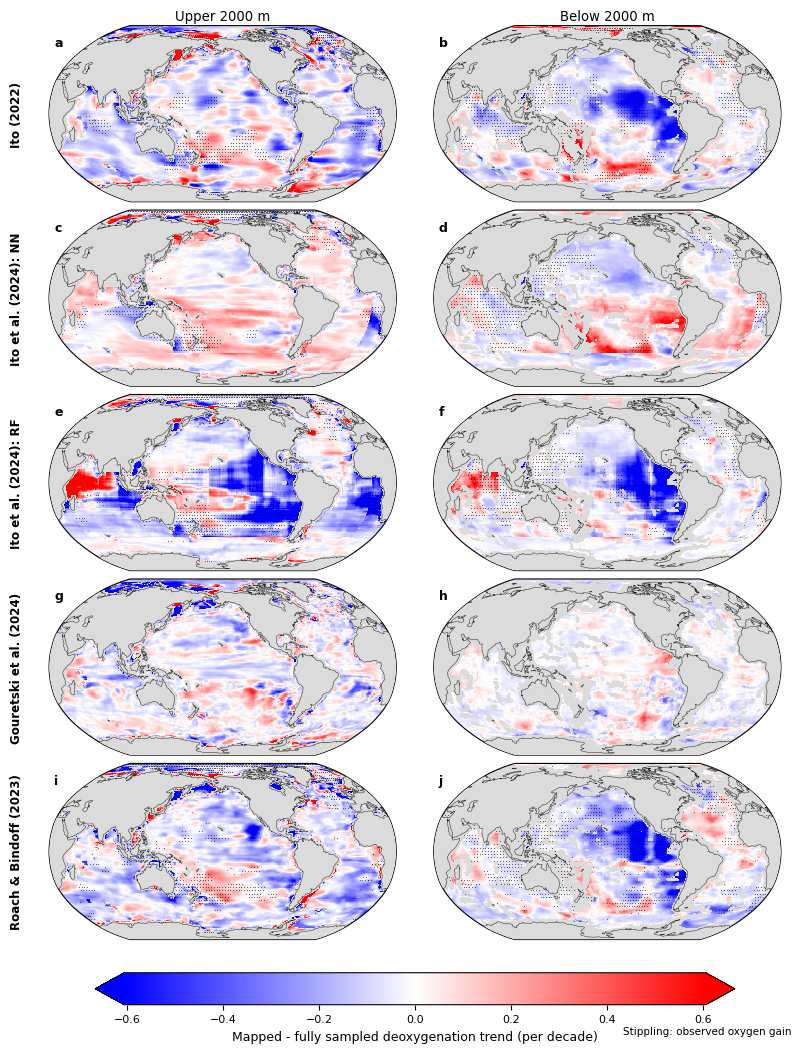

In [2]:
data = ds["difference"]
finite = data.to_numpy()
finite = finite[np.isfinite(finite)]
limit = max(abs(np.nanpercentile(finite, 2)), abs(np.nanpercentile(finite, 98)), 0.05)
projection = ccrs.Robinson(central_longitude=workflow.MAP_CENTRAL_LONGITUDE)
transform = ccrs.PlateCarree()
fig, axes = plt.subplots(
    len(workflow.global_pdf.PRODUCTS), len(workflow.DEPTH_COLUMNS),
    figsize=(8.0, 8.0 * 12.0 / 9.2), subplot_kw={"projection": projection},
    constrained_layout=True,
)
product_labels = [workflow.global_pdf.PRODUCT_LABELS[name] for name in workflow.global_pdf.PRODUCTS]
last = None
for row, product_label in enumerate(product_labels):
    for col, (depth_label, depth_key) in enumerate(workflow.DEPTH_COLUMNS.items()):
        ax = axes[row, col]
        field = data.sel(product=product_label, depth=depth_key)
        gain_mask = ds["oxygen_gain"].sel(product=product_label, depth=depth_key)
        plot_field = workflow.prepare_longitude_for_plot(field)
        invalid = xr.where(np.isfinite(plot_field), np.nan, 1.0)
        invalid.plot.pcolormesh(
            ax=ax, transform=transform, cmap=workflow.INVALID_CELL_CMAP, vmin=0, vmax=1,
            add_colorbar=False, rasterized=True, zorder=1,
        )
        last = plot_field.plot.pcolormesh(
            ax=ax, transform=transform, cmap="bwr", vmin=-limit, vmax=limit,
            add_colorbar=False, rasterized=True, zorder=2,
        )
        workflow.stipple_mask(ax, gain_mask, transform, use_cartopy=True)
        ax.add_feature(cfeature.LAND, facecolor="0.86", edgecolor="none", zorder=3)
        ax.coastlines(linewidth=0.35, color="0.15", zorder=5)
        ax.set_global()
        ax.set_title(depth_label if row == 0 else "", fontsize=9.5, pad=4)
        if col == 0:
            ax.text(-0.075, 0.5, product_label, transform=ax.transAxes, rotation=90,
                    va="center", ha="right", fontsize=8.5, fontweight="bold")
        ax.text(
            0.015, 0.94, chr(ord("a") + row * len(workflow.DEPTH_COLUMNS) + col),
            transform=ax.transAxes, va="top", ha="left", fontsize=9, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=1.6), zorder=6,
        )
cbar = fig.colorbar(last, ax=axes, orientation="horizontal", fraction=0.035, pad=0.035, extend="both")
cbar.set_label("Mapped - fully sampled deoxygenation trend (per decade)", fontsize=9)
cbar.ax.tick_params(labelsize=8)
fig.text(0.99, 0.012, "Stippling: observed oxygen gain", ha="right", va="bottom", fontsize=7.5)
fig.savefig(PNG_PATH, dpi=300)
fig.savefig(PDF_PATH)
print(f"Wrote {PNG_PATH}")
print(f"Wrote {PDF_PATH}")
plt.show()